In [3]:
from pathlib import Path

DATA_DIR = Path("../data/real_vs_fake/real-vs-fake")

train_dir = DATA_DIR / "train"
valid_dir = DATA_DIR / "valid"
test_dir = DATA_DIR / "test"

print("Train:", train_dir)
print("Valid:", valid_dir)
print("Test:", test_dir)

Train: ../data/real_vs_fake/real-vs-fake/train
Valid: ../data/real_vs_fake/real-vs-fake/valid
Test: ../data/real_vs_fake/real-vs-fake/test


In [4]:
import sys
import PIL

In [5]:
from PIL import Image

real_images = list((train_dir / "real").glob("*"))
fake_images = list((train_dir / "fake").glob("*"))

print("Real:", len(real_images))
print("Fake:", len(fake_images))

real_img = Image.open(real_images[0])

print(real_img.size)
print(real_img.mode)

Real: 50000
Fake: 50000
(256, 256)
RGB


Matplotlib is building the font cache; this may take a moment.


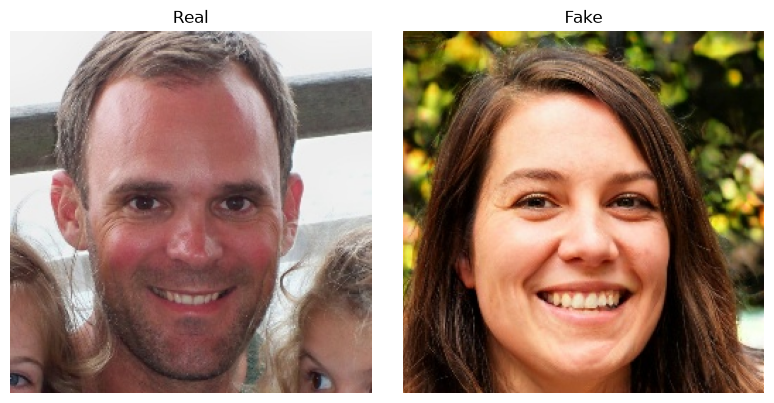

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(Image.open(real_images[0]))
axes[0].set_title("Real")
axes[0].axis("off")

axes[1].imshow(Image.open(fake_images[0]))
axes[1].set_title("Fake")
axes[1].axis("off")

plt.tight_layout()
plt.show()

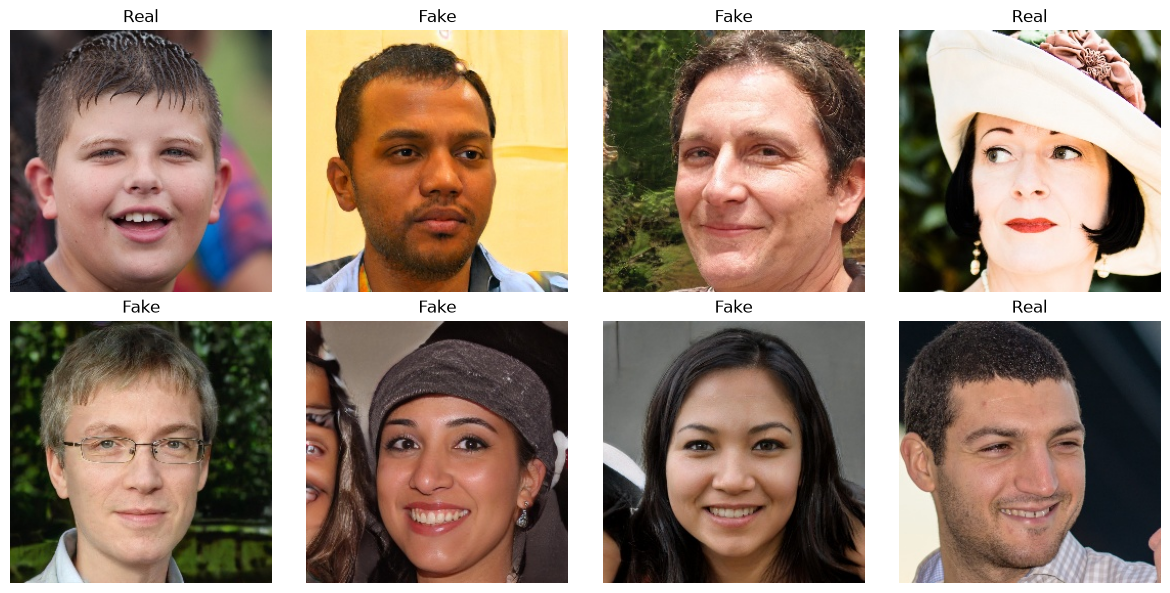

In [7]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flat:
    if random.random() < 0.5:
        img_path = random.choice(real_images)
        label = "Real"
    else:
        img_path = random.choice(fake_images)
        label = "Fake"

    ax.imshow(Image.open(img_path))
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from collections import Counter

real_sizes = Counter(
    Image.open(path).size
    for path in real_images[:1000]
)

fake_sizes = Counter(
    Image.open(path).size
    for path in fake_images[:1000]
)

print("Real sizes:", real_sizes)
print("Fake sizes:", fake_sizes)

Real sizes: Counter({(256, 256): 1000})
Fake sizes: Counter({(256, 256): 1000})


In [1]:
# 경로 찾기
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [11]:
from src.dataset import DeepfakeDataset

In [12]:
train_dataset = DeepfakeDataset(
    root_dir=train_dir
)

print("Dataset size:", len(train_dataset))

Dataset size: 100000


In [13]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Label:", label)

Image type: <class 'PIL.Image.Image'>
Label: 0


In [14]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
train_dataset = DeepfakeDataset(
    root_dir=train_dir,
    transform=train_transform
)

valid_dataset = DeepfakeDataset(
    root_dir=valid_dir,
    transform=valid_transform
)

test_dataset = DeepfakeDataset(
    root_dir=test_dir,
    transform=valid_transform
)

print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

100000
20000
20000


In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [17]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Labels:", labels[:10])

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Labels: tensor([0, 1, 0, 0, 1, 0, 0, 1, 0, 1])


In [19]:
print(images.min())
print(images.max())

tensor(-2.1179)
tensor(2.6400)


In [2]:
from src.model import create_model

model = create_model()

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/suaoh/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:10<00:00, 4.28MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [ ]:
# Device 설정
import torch

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [4]:
# Model 올리기
from src.model import create_model

model = create_model()
model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [6]:
# 실제 Image Batch 넣기
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Images :", images.shape)
print("Labels :", labels.shape)
print("Outputs:", outputs.shape)

NameError: name 'train_loader' is not defined